# 02 — Эксперименты по retrieval

Сравниваем три стратегии поиска (BM25, плотный, гибрид) и влияние `top_k`. Метрики и таблицы берём из артефактов, собранных `python -m src.train`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt


## Сравнение стратегий при top_k = 5

In [2]:
cmp = pd.read_csv(ROOT/'artifacts/retrieval_comparison.csv')
cmp[['method','hit@5','recall@5','mrr@5','ndcg@5']]

,method,hit@5,recall@5,mrr@5,ndcg@5
0,bm25,0.8462,0.8205,0.7436,0.7500
1,dense,0.8974,0.8718,0.7479,0.7735
2,hybrid,0.9231,0.9103,0.8098,0.8295


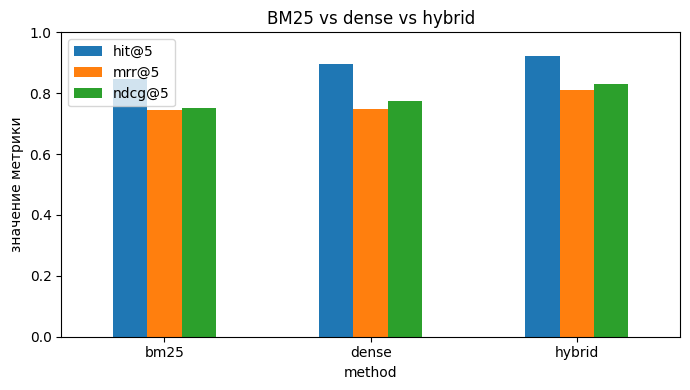

In [3]:
ax = cmp.set_index('method')[['hit@5','mrr@5','ndcg@5']].plot(kind='bar', figsize=(7,4))
ax.set_ylim(0,1); ax.set_title('BM25 vs dense vs hybrid'); ax.set_ylabel('значение метрики')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Гибрид заметно обгоняет одиночные ретриверы по MRR и nDCG: BM25 хорошо ловит точные термины, плотный поиск — перефразировки, а RRF объединяет сильные стороны обоих.

## Влияние top_k (гибрид)

Данные из общего лога экспериментов `experiments.csv`.

In [4]:
exp = pd.read_csv(ROOT/'artifacts/experiments.csv')
topk = exp[exp['run'].str.startswith('hybrid_topk')].copy()
# метрики лежат в колонках hit@k для разных k — соберём hit и mrr по фактическому k
def pick(row, prefix):
    k = int(row['top_k'])
    return row.get(f'{prefix}@{k}')
topk['hit'] = topk.apply(lambda r: pick(r,'hit'), axis=1)
topk['mrr'] = topk.apply(lambda r: pick(r,'mrr'), axis=1)
topk[['top_k','hit','mrr']].sort_values('top_k')

,top_k,hit,mrr
3,1,0.7179,0.7179
4,3,0.8974,0.8034
5,5,0.9231,0.8098
6,10,0.9744,0.8159


## Анализ ошибок

Где гибрид промахивается — смотрим запросы с hit = 0.

In [5]:
per_q = pd.read_csv(ROOT/'artifacts/eval_per_query.csv')
print('всего запросов:', len(per_q), '| промахов:', int((per_q['hit']==0).sum()))
per_q[per_q['hit']==0]

всего запросов: 39 | промахов: 3


,query,relevant,retrieved,hit
17,как подать декларацию для налогового вычета,tax-05,tax-02;mort-06;tax-04;dep-07;dep-05,0
32,в чём разница реальной и номинальной доходности,infl-03,cur-03;dep-02;dep-03;dep-07;cred-06,0
35,что делать если позвонили из банка и просят код,sec-04;sec-01,sec-06;card-01;sec-03;card-06;sec-02,0


**Вывод:** финальная конфигурация — гибридный поиск, `top_k=5`. Рост `top_k` до 10 поднимает recall, но добавляет нерелевантные источники в ответ. Большинство промахов приходится на запросы, где релевантны сразу несколько документов из смежных тем (например, налоговый вычет по ипотеке).